> **📝 내 메모** — (여기에 적기. 원본 셀은 건드리지 말고 새 셀로만 추가.)

> **⚙️ 원본에 없는 셀 (배윤진 추가)** — repo 루트의 `.env`(gitignored)에서 `QISKIT_IBM_*`
> 환경변수를 읽어온다. 이 노트북은 **전부 로컬**이라 사실 계정이 필요 없다. 커널은 `Python (qiskit-sg24)`.
>
> **이 파일은 한글 번역본.** 원본은 `2_Monitor_Jobs.ipynb`. 코드는 동일하고
> 주석·출력 문자열·설명만 번역했다. 연습문제에는 오답 해설을 추가했다.

In [1]:
import os
from pathlib import Path

env_path = next((p / ".env" for p in [Path.cwd(), *Path.cwd().parents] if (p / ".env").exists()), None)
if env_path:
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ[k.strip()] = v.strip()
print(f".env: {env_path or '없음'} · QISKIT_IBM_TOKEN {'설정됨' if os.getenv('QISKIT_IBM_TOKEN') else '없음'}")

.env: /home/annie/Qiskit-SG24/.env · QISKIT_IBM_TOKEN 설정됨


# 과제 7.2: Provider 이해하기와 job 모니터링

이 노트북은 `Provider`, `Backend`, `Job` 클래스로 이루어진 Qiskit provider 모델을 실습으로 다룹니다.

**목표:** 이 구성 요소들이 어떻게 맞물려 돌아가는지 이해하기 위해, 간단한 **커스텀 in-memory backend**를 직접 만들어 봅니다. 이 "가짜" backend는 실제 양자 계산을 하지는 않지만 Qiskit 인터페이스를 올바르게 구현하므로, job을 제출하고 결과를 받는 전체 흐름을 볼 수 있습니다.

## 목표 1: Provider, Backend, Job 추상 클래스

Qiskit provider 모델은 Qiskit이 다양한 실행 자원(backend)과 상호작용하는 방식을 정의하는 프레임워크입니다.

*   **`Provider`:** 진입점. backend 묶음을 관리하고 접근을 제공합니다 (예: `qiskit-ibm-provider`는 IBM backend들에 대한 접근을 제공).
*   **`BackendV2`:** backend의 현대적 인터페이스. backend의 능력(`target`)을 기술하고, circuit을 실행하는 `.run()` 메서드를 가집니다.
*   **`Job`:** `backend.run()`이 돌려주는 객체. 제출된 job을 나타내며 상태 확인(`.status()`)과 최종 결과 조회(`.result()`)에 씁니다.

### 1단계: 커스텀 `Job` 구현

먼저 job의 생명주기를 흉내 내는 간단한 `MyJob` 클래스를 만듭니다. 잠깐 "RUNNING"인 척하다가 미리 정해둔 가짜 결과를 돌려줍니다.

In [2]:
import time
import uuid
from qiskit.providers import JobV1 as Job, JobStatus, JobError
from qiskit.result import Result

class MyJob(Job):
    """시연용 간단한 in-memory job 클래스."""
    def __init__(self, backend, job_id, circuit):
        super().__init__(backend, job_id)
        self._status = JobStatus.QUEUED
        self._circuit = circuit
        self._result = self._create_fake_result()
        print(f"-> circuit '{self._circuit.name}'에 대한 Job {self._job_id} 생성.")

    def _create_fake_result(self):
        """정적인 가짜 result 객체를 만든다."""
        fake_counts = {'00': 512, '11': 512} # 완벽한 Bell state를 흉내 냄
        results_dict = {
            'backend_name': self._backend.name,
            'backend_version': self._backend.version,
            'job_id': self._job_id,
            'qobj_id': str(uuid.uuid4()),
            'success': True,
            'results': [
                {
                    'shots': 1024,
                    'success': True,
                    'header': {'name': self._circuit.name},
                    'data': {'counts': fake_counts}
                }
            ]
        }
        return Result.from_dict(results_dict)

    def submit(self):
        """job 제출을 흉내 낸다. RUNNING을 거쳐 DONE이 된다."""
        self._status = JobStatus.RUNNING
        print(f"-> Job {self._job_id} 상태: {self.status().name}.")
        # 실행 시간을 흉내 냄
        time.sleep(0.5)
        self._status = JobStatus.DONE
        print(f"-> Job {self._job_id} 상태: {self.status().name}.")

    def result(self):
        """가짜 result를 돌려준다."""
        if self._status is not JobStatus.DONE:
            raise JobError("Job이 아직 완료되지 않았습니다.")
        return self._result

    def status(self):
        """현재 job 상태를 돌려준다."""
        return self._status

print("MyJob 클래스 정의 완료!")

MyJob 클래스 정의 완료!


### 2단계: 커스텀 `BackendV2` 구현

다음으로 `MyBackend`를 만듭니다. 핵심 역할은 자신의 능력(`target`)을 정의하는 것과, `MyJob` 객체를 돌려주는 `.run()` 메서드를 갖는 것입니다.

**중요:** `BackendV2`는 backend의 기본 옵션을 정의하는 `_default_options()` 메서드를 반드시 구현해야 합니다.

In [3]:
from qiskit.circuit import Measure, Reset, Parameter
from qiskit.circuit.library import SXGate, CXGate, UGate
from qiskit.providers import BackendV2, Options
from qiskit.transpiler import Target

class MyBackend(BackendV2):
    """가짜 MyJob을 돌려주는 간단한 커스텀 backend."""
    def __init__(self, provider=None):
        super().__init__(name="my_custom_backend", backend_version="1.0")
        self._provider = provider

        # --- backend의 Target 정의 ---
        # Target은 이 backend가 정확히 어떤 gate와 operation을 지원하는지 기술한다.
        self._target = Target()
        theta = Parameter("theta")
        phi = Parameter("phi")
        lam = Parameter("lam")

        # 지원하는 instruction과 그 속성을 추가 (qubit 0-4 전부)
        self._target.add_instruction(UGate(theta, phi, lam), {(i,): None for i in range(5)})
        self._target.add_instruction(SXGate(), {(i,): None for i in range(5)})
        self._target.add_instruction(CXGate(), {(0, 1): None, (1, 2): None, (2, 3): None, (3, 4): None})
        self._target.add_instruction(Measure(), {(i,): None for i in range(5)})
        self._target.add_instruction(Reset(), {(i,): None for i in range(5)})

        print("-> MyBackend 초기화됨.")

    @property
    def target(self):
        return self._target

    @property
    def max_circuits(self):
        return 1

    @classmethod
    def _default_options(cls):
        """이 backend의 기본 옵션을 돌려준다."""
        return Options(shots=1024)

    def run(self, circuit, **kwargs):
        """MyJob 인스턴스를 만들고 제출하는 것으로 circuit을 '실행'한다."""
        job_id = str(uuid.uuid4())
        job = MyJob(backend=self, job_id=job_id, circuit=circuit)
        job.submit()
        return job

print("MyBackend 클래스 정의 완료!")

MyBackend 클래스 정의 완료!


### 3단계: 커스텀 `Provider` 구현

마지막으로 `MyProvider` 클래스가 우리 backend를 얻는 진입점 역할을 합니다. deprecated된 기반 클래스를 상속하지 않고 간단한 provider 클래스를 만듭니다.

In [4]:
class MyProvider:
    """MyBackend에 대한 접근을 제공하는 간단한 provider."""
    def __init__(self):
        self._backends = {"my_custom_backend": MyBackend(provider=self)}
        print("-> MyProvider 초기화됨.")

    def get_backend(self, name=None):
        """이름으로 backend를 가져온다."""
        if name is None:
            # 이름이 없으면 첫 번째 backend를 돌려준다
            return list(self._backends.values())[0]
        if name in self._backends:
            return self._backends[name]
        raise KeyError(f"Backend '{name}'을(를) 찾을 수 없습니다")

    def backends(self, name=None, **kwargs):
        """사용 가능한 backend 목록을 돌려준다."""
        if name:
            return [self._backends[name]] if name in self._backends else []
        return list(self._backends.values())

print("MyProvider 클래스 정의 완료!")

MyProvider 클래스 정의 완료!


## 전부 합치기: 전체 워크플로우 예제

이제 커스텀 provider와 backend를 다른 Qiskit provider와 똑같이 쓸 수 있습니다.

In [5]:
# 1. 커스텀 provider 인스턴스 생성
print("\n" + "="*60)
print("1단계: Provider 생성")
print("="*60)
my_provider = MyProvider()


1단계: Provider 생성
-> MyBackend 초기화됨.
-> MyProvider 초기화됨.


In [6]:
# 2. provider에서 커스텀 backend 가져오기
print("\n" + "="*60)
print("2단계: Backend 가져오기")
print("="*60)
my_backend = my_provider.get_backend("my_custom_backend")
print(f"Backend 이름: {my_backend.name}")
print(f"Backend 버전: {my_backend.version}")
print(f"Max circuits: {my_backend.max_circuits}")
print(f"기본 shots: {my_backend.options.shots}")


2단계: Backend 가져오기
Backend 이름: my_custom_backend
Backend 버전: 2
Max circuits: 1
기본 shots: 1024



3단계: Circuit 생성

원본 Circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


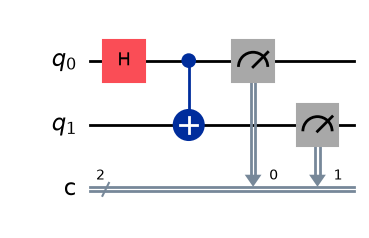

In [7]:
# 3. 실행할 circuit 만들기
from qiskit import QuantumCircuit

print("\n" + "="*60)
print("3단계: Circuit 생성")
print("="*60)
bell_circuit = QuantumCircuit(2, 2, name="bell_state")
bell_circuit.h(0)
bell_circuit.cx(0, 1)
bell_circuit.measure([0, 1], [0, 1])

print("\n원본 Circuit:")
print(bell_circuit)
bell_circuit.draw('mpl')


4단계: Circuit Transpile



Transpile된 Circuit (backend의 basis gate 사용):
         ┌────────────┐     ┌─┐   
q_0 -> 0 ┤ U(π/2,0,π) ├──■──┤M├───
         └────────────┘┌─┴─┐└╥┘┌─┐
q_1 -> 1 ──────────────┤ X ├─╫─┤M├
                       └───┘ ║ └╥┘
    c: 2/════════════════════╩══╩═
                             0  1 


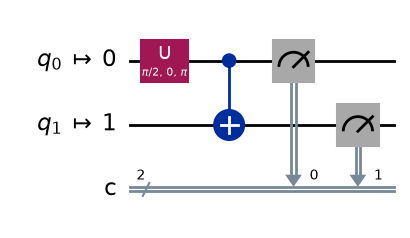

In [8]:
# 4. backend의 target에 맞게 circuit transpile
from qiskit import transpile
# circuit이 backend가 지원하는 gate만 쓰도록 만드는 필수 단계다.
print("\n" + "="*60)
print("4단계: Circuit Transpile")
print("="*60)
transpiled_circuit = transpile(bell_circuit, backend=my_backend)
print("\nTranspile된 Circuit (backend의 basis gate 사용):")
print(transpiled_circuit)
transpiled_circuit.draw('mpl')

### job 제출과 상태 모니터링

`.run()` 메서드는 `MyJob` 객체를 돌려줍니다. 이걸로 상태를 확인하고 결과를 받을 수 있습니다.

In [9]:
# 5. transpile된 circuit을 backend에서 실행
print("\n" + "="*60)
print("5단계: Job 실행")
print("="*60)
job = my_backend.run(transpiled_circuit)

# 6. 최종 상태 확인
print(f"\nJob 최종 상태: {job.status()}")
print(f"Job ID: {job.job_id()}")


5단계: Job 실행
-> circuit 'bell_state'에 대한 Job 17af5d65-33cf-4342-ba14-ca42ddf08658 생성.
-> Job 17af5d65-33cf-4342-ba14-ca42ddf08658 상태: RUNNING.


-> Job 17af5d65-33cf-4342-ba14-ca42ddf08658 상태: DONE.

Job 최종 상태: JobStatus.DONE
Job ID: 17af5d65-33cf-4342-ba14-ca42ddf08658


In [10]:
# 7. 결과 받기
print("\n" + "="*60)
print("6단계: 결과 조회")
print("="*60)
result = job.result()
counts = result.get_counts()
print(f"\n결과 counts: {counts}")
print(f"\nResult metadata:")
print(f"  Backend: {result.backend_name}")
print(f"  Job ID: {result.job_id}")
print(f"  Success: {result.success}")


6단계: 결과 조회

결과 counts: {'00': 512, '11': 512}

Result metadata:
  Backend: my_custom_backend
  Job ID: 17af5d65-33cf-4342-ba14-ca42ddf08658
  Success: True



결과 histogram:


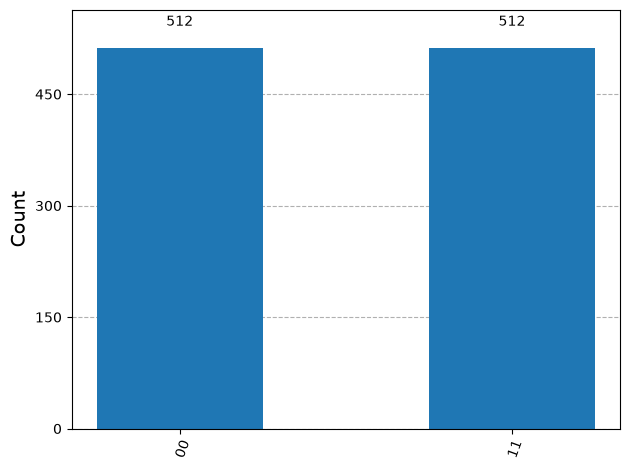

In [11]:
# 8. 결과 histogram 그리기
from qiskit.visualization import plot_histogram

print("\n결과 histogram:")
plot_histogram(counts)

## Target 이해하기

`Target` 객체는 transpile에 핵심적입니다. 우리 backend가 지원한다고 보고하는 operation을 살펴봅시다.

In [12]:
# backend에서 target 가져오기
target = my_backend.target

print("Backend Target 정보:")
print(f"  Qubit 수: {target.num_qubits}")
print(f"\n지원하는 operation:")
for operation in target.operations:
    print(f"  - {operation}")

print(f"\noperation별 지원 instruction:")
for instruction_name in target.operation_names:
    qargs = target.qargs_for_operation_name(instruction_name)
    print(f"  {instruction_name}: {len(qargs)}개 구성")

Backend Target 정보:
  Qubit 수: 5

지원하는 operation:
  - Instruction(name='u', num_qubits=1, num_clbits=0, params=[Parameter(theta), Parameter(phi), Parameter(lam)])
  - Instruction(name='sx', num_qubits=1, num_clbits=0, params=[])
  - Instruction(name='cx', num_qubits=2, num_clbits=0, params=[])
  - Instruction(name='measure', num_qubits=1, num_clbits=1, params=[])
  - Instruction(name='reset', num_qubits=1, num_clbits=0, params=[])

operation별 지원 instruction:
  u: 5개 구성
  sx: 5개 구성
  cx: 4개 구성
  measure: 5개 구성
  reset: 5개 구성


## 목표 2: JobStatus 열거형

`JobStatus` 열거형은 job이 생명주기 동안 가질 수 있는 여러 상태를 나타냅니다. 가능한 상태를 전부 살펴봅시다.

In [13]:
from qiskit.providers import JobStatus

print("가능한 JobStatus 값 전부:")
print("="*60)
for status in JobStatus:
    print(f"  {status.name:15} - 값: {status.value}")

print("\n일반적인 job 생명주기:")
print("  INITIALIZING → QUEUED → VALIDATING → RUNNING → DONE")
print("\n가능한 종료 상태:")
print("  - DONE: job이 성공적으로 완료됨")
print("  - ERROR: job에서 에러 발생")
print("  - CANCELLED: 사용자가 job을 취소함")

가능한 JobStatus 값 전부:
  INITIALIZING    - 값: job is being initialized
  QUEUED          - 값: job is queued
  VALIDATING      - 값: job is being validated
  RUNNING         - 값: job is actively running
  CANCELLED       - 값: job has been cancelled
  DONE            - 값: job has successfully run
  ERROR           - 값: job incurred error

일반적인 job 생명주기:
  INITIALIZING → QUEUED → VALIDATING → RUNNING → DONE

가능한 종료 상태:
  - DONE: job이 성공적으로 완료됨
  - ERROR: job에서 에러 발생
  - CANCELLED: 사용자가 job을 취소함


## 목표 3: Session (Runtime 전용 개념)

**`Session`**은 `qiskit-ibm-runtime`의 개념으로, backend에 대한 전용 연결을 관리해 여러 job을 효율적으로 실행하는 데 씁니다.

### 핵심 포인트:

- Session은 **IBM Quantum Runtime 서비스 전용**
- 여러 job을 위해 backend 시간을 예약할 수 있음
- 같은 session 안의 후속 job들은 대기 시간이 줄어듦
- 우리가 만든 커스텀 `BackendV2`는 session을 지원하지 않음 (runtime 서비스가 아니므로)

### Session 속성:
- `service`: QiskitRuntimeService 인스턴스
- `session_id`: session 고유 식별자

### Session 메서드:
- `backend()`: session의 backend 가져오기
- `cancel()`: session 안의 모든 job 취소
- `close()`: session 닫기
- `details()`: session 상세 정보
- `from_id()`: 기존 ID로 session 객체 만들기
- `status()`: session 상태
- `usage()`: 자원 사용량 통계

In [14]:
# Session 사용 예시 (IBM Quantum 계정 필요)
print("Session 사용 예시 (클라우드 전용):")
print("="*60)
print("""
# IBM Quantum Runtime에서:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

# 여러 job을 돌릴 session 생성
with Session(service=service, backend=backend) as session:
    sampler = SamplerV2(session=session)

    # 같은 session 안에서 job 여러 개 실행
    job1 = sampler.run([circuit1])
    job2 = sampler.run([circuit2])
    job3 = sampler.run([circuit3])

    # 결과 받기
    result1 = job1.result()
    result2 = job2.result()
    result3 = job3.result()

    # session 정보 확인
    print(f"Session ID: {session.session_id}")
    print(f"Session status: {session.status()}")
    print(f"Session usage: {session.usage()}")

# 'with' 블록을 나가면 session이 자동으로 닫힌다
""")

Session 사용 예시 (클라우드 전용):

# IBM Quantum Runtime에서:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

# 여러 job을 돌릴 session 생성
with Session(service=service, backend=backend) as session:
    sampler = SamplerV2(session=session)

    # 같은 session 안에서 job 여러 개 실행
    job1 = sampler.run([circuit1])
    job2 = sampler.run([circuit2])
    job3 = sampler.run([circuit3])

    # 결과 받기
    result1 = job1.result()
    result2 = job2.result()
    result3 = job3.result()

    # session 정보 확인
    print(f"Session ID: {session.session_id}")
    print(f"Session status: {session.status()}")
    print(f"Session usage: {session.usage()}")

# 'with' 블록을 나가면 session이 자동으로 닫힌다



## 요약

이 노트북에서 다룬 것:

1. **Provider 모델**:
   - backend를 관리하는 커스텀 `Provider` 구현
   - `Target`을 정의한 커스텀 `BackendV2` 구현
   - job 생명주기를 다루는 커스텀 `Job` 클래스 구현
   - 필수 메서드 `_default_options()` 구현

2. **전체 워크플로우**:
   - quantum circuit 생성
   - backend의 basis gate에 맞게 transpile
   - job 제출과 상태 모니터링
   - 결과 조회와 시각화

3. **JobStatus**: job 상태를 나타내는 열거형

4. **Session**: 여러 job을 효율적으로 실행하기 위한 runtime 전용 기능

이런 실습을 통해 Qiskit의 provider 모델이 다양한 양자 컴퓨팅 backend를 통합할 수 있는 유연하고 확장 가능한 프레임워크임을 확인했습니다!

## 연습문제

**1. Qiskit Provider 모델에서 backend의 물리적 능력(지원 gate, qubit 등)을 기술하는 객체는?**

A) `Provider` 클래스

B) `Target` 객체 (`backend.target`)

C) `Options` 클래스

D) `Job` 클래스

***정답:***
<Details>
<br/>

**B) `Target` 객체 (`backend.target`)**

이 노트북 [8]의 `MyBackend.__init__`이 그대로 답이다. `Target()`을 만들고 `add_instruction()`으로
"어떤 gate를 어떤 qubit(쌍)에 쓸 수 있는지"를 등록한다. [21]에서 `target.num_qubits`,
`target.operations`, `target.qargs_for_operation_name()`으로 그 내용을 다시 읽어낸다.
transpiler는 이 Target을 보고 circuit을 backend가 실행 가능한 형태로 바꾼다 ([15]).

**오답 해설**

| 보기 | 왜 틀림 |
| --- | --- |
| A) `Provider` | backend **목록**을 관리하고 꺼내주는 진입점 (`get_backend`, `backends`). backend가 뭘 할 수 있는지는 모른다 — [10]의 `MyProvider`에 gate 얘기가 하나도 없다 |
| C) `Options` | **실행 옵션** (shots 등). [8]의 `_default_options()`가 `Options(shots=1024)`를 돌려주는 게 전부. 물리적 능력이 아니라 "이번 실행을 어떻게 할지" |
| D) `Job` | 제출된 작업의 **handle**. 상태 확인과 결과 조회용 ([6]). backend 능력과 무관 |
</Details>

---

**2. Qiskit Runtime에서 `Session`을 쓰는 주된 이점은?**

A) 인터넷 연결 없이 오프라인으로 job을 실행할 수 있다

B) 결과에 에러가 없음을 보장한다

C) 대기 지연을 줄여 여러 job을 효율적으로 실행할 수 있다

D) backend에서 쓸 수 있는 qubit 수가 늘어난다

***정답:***
<Details>
<br/>

**C) 대기 지연을 줄여 여러 job을 효율적으로 실행할 수 있다**

[24]의 핵심 포인트 그대로: session은 backend에 대한 **전용 시간창**을 열어, 같은 session 안의
후속 job들이 큐를 다시 서지 않게 한다. 반복적으로 양자↔고전을 오가는 작업(VQE 등)에 쓴다.
(week4 노트북에서 배운 것: session은 batch보다 비싸고, Open plan은 못 쓴다.)

**오답 해설**

| 보기 | 왜 틀림 |
| --- | --- |
| A) 오프라인 | 정반대. Session은 **IBM Quantum Runtime 서비스 전용** 개념이라 `QiskitRuntimeService()` 연결이 전제다. [24]에 "우리 커스텀 backend는 session을 지원하지 않는다 — runtime 서비스가 아니므로"라고 명시 |
| B) 에러 없음 보장 | Session은 **스케줄링** 기능이지 결과 품질과 무관. 에러 완화는 primitive의 `resilience`/`options` 쪽 얘기고, 그것도 "보장"은 아니다 |
| D) qubit 증가 | 하드웨어 qubit 수는 물리적으로 고정. session이 바꿀 수 있는 건 *언제* 돌리느냐뿐 |
</Details>

---

**3. job이 성공적으로 실행을 마쳤음을 나타내는 `JobStatus`는?**

A) `JobStatus.RUNNING`

B) `JobStatus.QUEUED`

C) `JobStatus.DONE`

D) `JobStatus.VALIDATING`

***정답:***
<Details>
<br/>

**C) `JobStatus.DONE`**

[23] 출력의 생명주기: `INITIALIZING → QUEUED → VALIDATING → RUNNING → DONE`.
종료 상태는 셋 — `DONE`(성공), `ERROR`(실패), `CANCELLED`(취소). 이 중 "성공"은 `DONE`뿐이다.
enum 값 자체가 `'job has successfully run'`이다.

**오답 해설**

| 보기 | 왜 틀림 |
| --- | --- |
| A) `RUNNING` | 지금 **실행 중**. 아직 안 끝남. [6]의 `MyJob.submit()`이 `RUNNING`을 거쳐 `DONE`으로 가는 걸 보라 |
| B) `QUEUED` | **대기열**에 있음. 실행 시작도 안 함. [6]에서 `MyJob`의 초기 상태 |
| D) `VALIDATING` | 제출된 job을 **검증 중**. `QUEUED` 다음, `RUNNING` 전 단계 |

함정 주의: `ERROR`와 `CANCELLED`도 "끝난" 상태지만 성공이 아니다. 그래서 1번 노트북 연습문제 2번에서
`in_final_state()`(셋 다 True)가 아니라 `done()`(`DONE`만 True)을 써야 했던 것.
</Details>